# 📊 Comprehensive Daily EDA - Market Analysis Dashboard

**Leveraging TradingView Screener for Market Intelligence**

This notebook provides:
- 📈 **Market-wide Analysis**: Overall market trends and movements
- 🏢 **Sector-wise Analysis**: Performance across different sectors
- 🔍 **Stock Screening**: Volume breakouts, support/resistance levels
- 📊 **Statistical Insights**: Data-driven market intelligence
- 🎯 **Trading Opportunities**: Actionable insights for trading

---

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# TradingView screener - using Column instead of col
from tradingview_screener import Query, Column
import rookiepy

# Create column function alias for compatibility  
col = Column

# Date and time
from datetime import datetime, timedelta
import pytz

# Rich for better console output
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich.progress import Progress

# Set up styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
console = Console()

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("🚀 Comprehensive Daily EDA - Market Analysis Dashboard Loaded!")

📅 Analysis Date: 2025-08-08 08:27:48
🚀 Comprehensive Daily EDA - Market Analysis Dashboard Loaded!


## 🔧 TradingView Setup & Authentication

Setting up TradingView screener with browser cookies for live data access.

In [2]:
def get_tradingview_cookies():
    """Get TradingView cookies from browser for live data access"""
    try:
        # Try Chrome first
        cookies_raw = rookiepy.chrome(['.tradingview.com'])
        cookies = rookiepy.to_cookiejar(cookies_raw)
        console.print("[green]✅ Successfully loaded TradingView cookies from Chrome[/green]")
        
        if cookies_raw:
            console.print("[green]🔥 Live TradingView data access enabled[/green]")
        else:
            console.print("[yellow]⚠️ No cookies found - using delayed data[/yellow]")
        
        return cookies
    except Exception:
        console.print("[yellow]Chrome failed, trying Firefox...[/yellow]")
        try:
            cookies_raw = rookiepy.firefox(['.tradingview.com'])
            cookies = rookiepy.to_cookiejar(cookies_raw)
            console.print("[green]✅ Successfully loaded TradingView cookies from Firefox[/green]")
            return cookies
        except Exception as e:
            console.print(f"[red]❌ Could not load cookies: {e}[/red]")
            console.print("[yellow]💡 Please ensure you're logged into TradingView in your browser[/yellow]")
            return None

# Initialize TradingView connection
tv_cookies = get_tradingview_cookies()
query = Query()

# Market settings
MARKET = 'india'  # Change to 'america' for US markets
EXCHANGE = 'NSE'  # NSE for India, 'NASDAQ' or 'NYSE' for US

console.print(f"[blue]🌏 Market Focus: {MARKET.upper()} | Exchange: {EXCHANGE}[/blue]")

✅ Successfully loaded TradingView cookies from Chrome

🔥 Live TradingView data access enabled

🌏 Market Focus: INDIA | Exchange: NSE

## 📈 Market Overview & Broad Analysis

Getting a comprehensive view of the overall market performance, top movers, and general sentiment indicators.

Output()

✅ Retrieved 100 stocks from 2,999 total matches

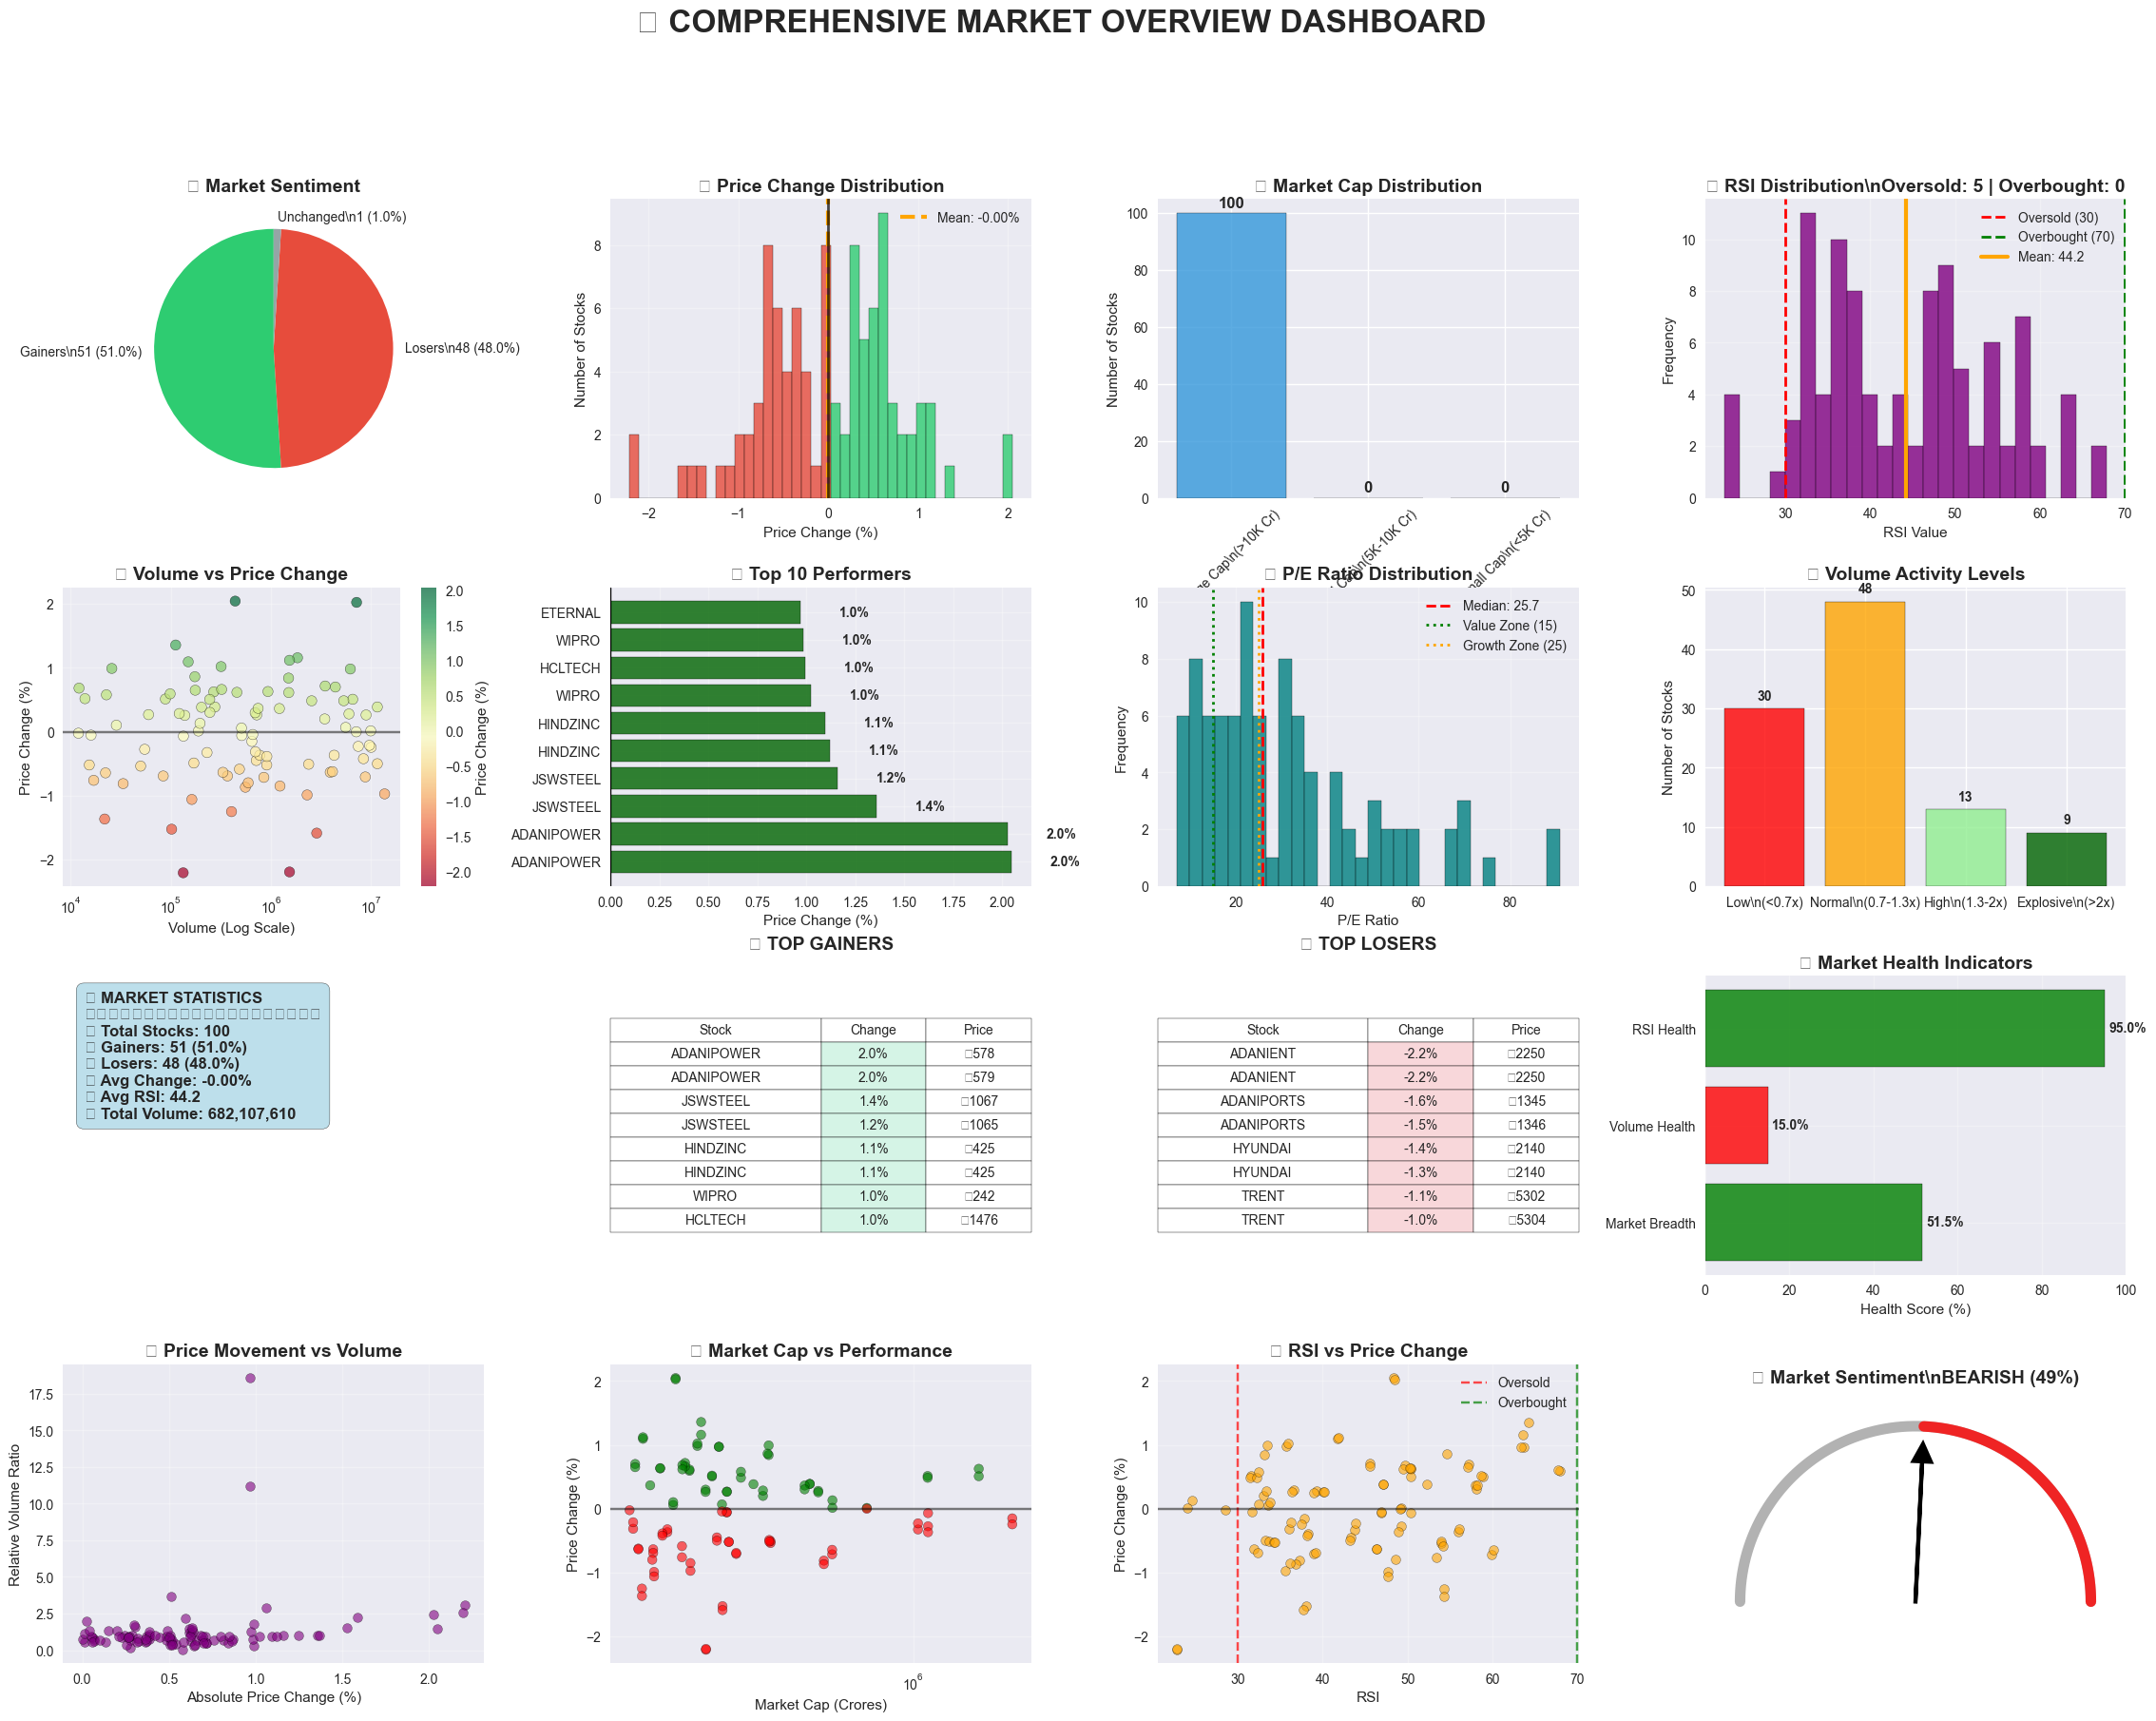

✅ Visual market dashboard created with 100 stocks

In [3]:
def get_market_overview(limit=100):
    """Get comprehensive market overview data"""
    
    col = Column
    
    market_query = (Query()
        .select('name', 'close', 'change', 'volume', 'market_cap_basic', 
                'price_earnings_ttm', 'relative_volume_10d_calc', 'RSI')
        .set_markets('india')
        .where(
            col('market_cap_basic') > 1_000_000_000,
            col('close') > 10,
            col('volume') > 10_000
        )
        .order_by('market_cap_basic', ascending=False)
        .limit(limit))
    
    try:
        data = market_query.get_scanner_data(cookies=tv_cookies)
        
        if data and len(data) >= 2:
            total_count = data[0]
            df = data[1]
            
            # Clean and convert data types
            numeric_cols = ['close', 'change', 'volume', 'market_cap_basic', 
                          'price_earnings_ttm', 'relative_volume_10d_calc', 'RSI']
            
            for col_name in numeric_cols:
                if col_name in df.columns:
                    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
            
            # Add derived metrics
            if 'market_cap_basic' in df.columns:
                df['market_cap_cr'] = df['market_cap_basic'] / 10_000_000
            if 'change' in df.columns:
                df['change_abs'] = abs(df['change'])
            
            console.print(f"[green]✅ Retrieved {len(df)} stocks from {total_count:,} total matches[/green]")
            return df
        else:
            console.print("[red]❌ No market data retrieved[/red]")
            return None
            
    except Exception as e:
        console.print(f"[red]❌ Error fetching market overview: {e}[/red]")
        return None

# Get market data
with console.status("[bold green]Fetching market overview data..."):
    market_df = get_market_overview()

if market_df is not None:
    # Create comprehensive visual market dashboard
    fig = plt.figure(figsize=(28, 20))
    gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)
    fig.suptitle('📊 COMPREHENSIVE MARKET OVERVIEW DASHBOARD', fontsize=24, fontweight='bold', y=0.98)
    
    # 1. Market Sentiment Pie Chart (Top Left)
    ax1 = fig.add_subplot(gs[0, 0])
    gainers = len(market_df[market_df['change'] > 0])
    losers = len(market_df[market_df['change'] < 0])
    unchanged = len(market_df) - gainers - losers
    
    sizes = [gainers, losers, unchanged]
    colors = ['#2ecc71', '#e74c3c', '#95a5a6']
    labels = [f'Gainers\\n{gainers} ({gainers/len(market_df)*100:.1f}%)',
              f'Losers\\n{losers} ({losers/len(market_df)*100:.1f}%)',
              f'Unchanged\\n{unchanged} ({unchanged/len(market_df)*100:.1f}%)']
    
    wedges, texts, autotexts = ax1.pie(sizes, labels=labels, colors=colors, autopct='', 
                                       startangle=90, textprops={'fontsize': 10})
    ax1.set_title('📈 Market Sentiment', fontsize=14, fontweight='bold')
    
    # 2. Price Change Distribution (Top Middle-Left)
    ax2 = fig.add_subplot(gs[0, 1])
    if 'change' in market_df.columns:
        n, bins, patches = ax2.hist(market_df['change'], bins=40, alpha=0.8, color='skyblue', edgecolor='black')
        
        # Color code histogram bars
        for i, patch in enumerate(patches):
            if bins[i] < 0:
                patch.set_facecolor('#e74c3c')
            elif bins[i] > 0:
                patch.set_facecolor('#2ecc71')
            else:
                patch.set_facecolor('#95a5a6')
        
        ax2.axvline(market_df['change'].mean(), color='orange', linestyle='--', linewidth=3, 
                    label=f'Mean: {market_df["change"].mean():.2f}%')
        ax2.axvline(0, color='black', linestyle='-', linewidth=2, alpha=0.7)
        ax2.set_title('📊 Price Change Distribution', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Price Change (%)')
        ax2.set_ylabel('Number of Stocks')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # 3. Market Cap Distribution (Top Middle-Right)
    ax3 = fig.add_subplot(gs[0, 2])
    if 'market_cap_cr' in market_df.columns:
        # Create market cap categories
        large_cap = len(market_df[market_df['market_cap_cr'] > 10000])
        mid_cap = len(market_df[(market_df['market_cap_cr'] > 5000) & (market_df['market_cap_cr'] <= 10000)])
        small_cap = len(market_df[market_df['market_cap_cr'] <= 5000])
        
        categories = ['Large Cap\\n(>10K Cr)', 'Mid Cap\\n(5K-10K Cr)', 'Small Cap\\n(<5K Cr)']
        values = [large_cap, mid_cap, small_cap]
        colors_cap = ['#3498db', '#f39c12', '#9b59b6']
        
        bars = ax3.bar(categories, values, color=colors_cap, alpha=0.8, edgecolor='black')
        ax3.set_title('🏢 Market Cap Distribution', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Number of Stocks')
        
        # Add value labels
        for bar, value in zip(bars, values):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    str(value), ha='center', va='bottom', fontweight='bold', fontsize=12)
        ax3.tick_params(axis='x', rotation=45)
    
    # 4. RSI Distribution (Top Right)
    ax4 = fig.add_subplot(gs[0, 3])
    if 'RSI' in market_df.columns:
        rsi_data = market_df['RSI'].dropna()
        ax4.hist(rsi_data, bins=25, alpha=0.8, color='purple', edgecolor='black')
        ax4.axvline(30, color='red', linestyle='--', linewidth=2, label='Oversold (30)')
        ax4.axvline(70, color='green', linestyle='--', linewidth=2, label='Overbought (70)')
        ax4.axvline(rsi_data.mean(), color='orange', linestyle='-', linewidth=3, 
                   label=f'Mean: {rsi_data.mean():.1f}')
        
        # RSI zones
        oversold = len(rsi_data[rsi_data < 30])
        overbought = len(rsi_data[rsi_data > 70])
        
        ax4.set_title(f'📊 RSI Distribution\\nOversold: {oversold} | Overbought: {overbought}', 
                     fontsize=14, fontweight='bold')
        ax4.set_xlabel('RSI Value')
        ax4.set_ylabel('Frequency')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    
    # 5. Volume vs Price Change Scatter (Second Row Left)
    ax5 = fig.add_subplot(gs[1, 0])
    if 'volume' in market_df.columns and 'change' in market_df.columns:
        df_filtered = market_df[(market_df['volume'] > 0) & (market_df['volume'] < market_df['volume'].quantile(0.95))]
        
        scatter = ax5.scatter(df_filtered['volume'], df_filtered['change'], 
                             c=df_filtered['change'], cmap='RdYlGn', alpha=0.7, s=60, edgecolor='black')
        ax5.set_title('📊 Volume vs Price Change', fontsize=14, fontweight='bold')
        ax5.set_xlabel('Volume (Log Scale)')
        ax5.set_ylabel('Price Change (%)')
        ax5.set_xscale('log')
        ax5.axhline(0, color='black', linestyle='-', alpha=0.5)
        plt.colorbar(scatter, ax=ax5, label='Price Change (%)')
        ax5.grid(True, alpha=0.3)
    
    # 6. Top 10 Performers Bar Chart (Second Row Middle-Left)
    ax6 = fig.add_subplot(gs[1, 1])
    if 'change' in market_df.columns and 'name' in market_df.columns:
        top_performers = market_df.nlargest(10, 'change')[['name', 'change']]
        
        colors_perf = ['darkgreen' if x > 0 else 'darkred' for x in top_performers['change']]
        bars = ax6.barh(range(len(top_performers)), top_performers['change'], 
                       color=colors_perf, alpha=0.8, edgecolor='black')
        ax6.set_yticks(range(len(top_performers)))
        ax6.set_yticklabels([name[:12] + '...' if len(name) > 12 else name for name in top_performers['name']], 
                           fontsize=10)
        ax6.set_title('🏆 Top 10 Performers', fontsize=14, fontweight='bold')
        ax6.set_xlabel('Price Change (%)')
        ax6.axvline(0, color='black', linewidth=1)
        
        # Add value labels
        for i, (bar, value) in enumerate(zip(bars, top_performers['change'])):
            ax6.text(value + (0.2 if value > 0 else -0.2), i, f'{value:.1f}%', 
                    ha='left' if value > 0 else 'right', va='center', fontweight='bold')
        ax6.grid(True, alpha=0.3)
    
    # 7. P/E Ratio Distribution (Second Row Middle-Right)
    ax7 = fig.add_subplot(gs[1, 2])
    if 'price_earnings_ttm' in market_df.columns:
        pe_data = market_df['price_earnings_ttm'].dropna()
        pe_filtered = pe_data[(pe_data > 0) & (pe_data < 100)]  # Filter extreme values
        
        ax7.hist(pe_filtered, bins=30, alpha=0.8, color='teal', edgecolor='black')
        ax7.axvline(pe_filtered.median(), color='red', linestyle='--', linewidth=2, 
                   label=f'Median: {pe_filtered.median():.1f}')
        ax7.axvline(15, color='green', linestyle=':', linewidth=2, label='Value Zone (15)')
        ax7.axvline(25, color='orange', linestyle=':', linewidth=2, label='Growth Zone (25)')
        
        ax7.set_title('💰 P/E Ratio Distribution', fontsize=14, fontweight='bold')
        ax7.set_xlabel('P/E Ratio')
        ax7.set_ylabel('Frequency')
        ax7.legend()
        ax7.grid(True, alpha=0.3)
    
    # 8. Volume Ratio Analysis (Second Row Right)
    ax8 = fig.add_subplot(gs[1, 3])
    if 'relative_volume_10d_calc' in market_df.columns:
        vol_ratio_data = market_df['relative_volume_10d_calc'].dropna()
        
        # Volume categories
        low_vol = len(vol_ratio_data[vol_ratio_data < 0.7])
        normal_vol = len(vol_ratio_data[(vol_ratio_data >= 0.7) & (vol_ratio_data < 1.3)])
        high_vol = len(vol_ratio_data[(vol_ratio_data >= 1.3) & (vol_ratio_data < 2.0)])
        explosive_vol = len(vol_ratio_data[vol_ratio_data >= 2.0])
        
        categories = ['Low\\n(<0.7x)', 'Normal\\n(0.7-1.3x)', 'High\\n(1.3-2x)', 'Explosive\\n(>2x)']
        values = [low_vol, normal_vol, high_vol, explosive_vol]
        colors_vol = ['red', 'orange', 'lightgreen', 'darkgreen']
        
        bars = ax8.bar(categories, values, color=colors_vol, alpha=0.8, edgecolor='black')
        ax8.set_title('📊 Volume Activity Levels', fontsize=14, fontweight='bold')
        ax8.set_ylabel('Number of Stocks')
        
        # Add value labels
        for bar, value in zip(bars, values):
            ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    str(value), ha='center', va='bottom', fontweight='bold')
    
    # 9-12. Market Summary Statistics (Bottom two rows)
    # 9. Market Statistics Box (Third Row Left)
    ax9 = fig.add_subplot(gs[2, 0])
    ax9.axis('off')
    
    stats_text = f"""📊 MARKET STATISTICS
━━━━━━━━━━━━━━━━━━━━
📈 Total Stocks: {len(market_df):,}
🟢 Gainers: {gainers:,} ({gainers/len(market_df)*100:.1f}%)
🔴 Losers: {losers:,} ({losers/len(market_df)*100:.1f}%)
📊 Avg Change: {market_df['change'].mean():.2f}%
📈 Avg RSI: {market_df['RSI'].mean():.1f}
💰 Total Volume: {market_df['volume'].sum():,.0f}"""
    
    ax9.text(0.05, 0.95, stats_text, transform=ax9.transAxes, fontsize=12, 
            verticalalignment='top', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
    
    # 10. Top Gainers Table (Third Row Middle-Left)
    ax10 = fig.add_subplot(gs[2, 1])
    ax10.axis('off')
    
    if 'change' in market_df.columns:
        top_gainers = market_df.nlargest(8, 'change')[['name', 'change', 'close']]
        
        table_data = []
        for _, row in top_gainers.iterrows():
            table_data.append([row['name'][:12] + ('...' if len(row['name']) > 12 else ''), 
                             f"{row['change']:.1f}%", f"₹{row['close']:.0f}"])
        
        table = ax10.table(cellText=table_data, 
                          colLabels=['Stock', 'Change', 'Price'],
                          cellLoc='center',
                          loc='center',
                          colWidths=[0.5, 0.25, 0.25])
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 1.5)
        
        # Color code the table
        for i in range(len(table_data)):
            table[(i+1, 1)].set_facecolor('#d5f4e6')  # Light green for positive changes
        
        ax10.set_title('🚀 TOP GAINERS', fontsize=14, fontweight='bold', pad=20)
    
    # 11. Top Losers Table (Third Row Middle-Right)
    ax11 = fig.add_subplot(gs[2, 2])
    ax11.axis('off')
    
    if 'change' in market_df.columns:
        top_losers = market_df.nsmallest(8, 'change')[['name', 'change', 'close']]
        
        table_data_losers = []
        for _, row in top_losers.iterrows():
            table_data_losers.append([row['name'][:12] + ('...' if len(row['name']) > 12 else ''), 
                                    f"{row['change']:.1f}%", f"₹{row['close']:.0f}"])
        
        table_losers = ax11.table(cellText=table_data_losers,
                                colLabels=['Stock', 'Change', 'Price'],
                                cellLoc='center',
                                loc='center',
                                colWidths=[0.5, 0.25, 0.25])
        table_losers.auto_set_font_size(False)
        table_losers.set_fontsize(10)
        table_losers.scale(1, 1.5)
        
        # Color code the table
        for i in range(len(table_data_losers)):
            table_losers[(i+1, 1)].set_facecolor('#f8d7da')  # Light red for negative changes
        
        ax11.set_title('📉 TOP LOSERS', fontsize=14, fontweight='bold', pad=20)
    
    # 12. Market Health Indicators (Third Row Right)
    ax12 = fig.add_subplot(gs[2, 3])
    
    # Create market health indicators
    health_metrics = []
    health_values = []
    health_colors = []
    
    # Breadth indicator
    breadth_ratio = gainers / (gainers + losers) * 100
    health_metrics.append('Market Breadth')
    health_values.append(breadth_ratio)
    health_colors.append('green' if breadth_ratio > 50 else 'red')
    
    # Volume health
    high_vol_stocks = len(market_df[market_df['relative_volume_10d_calc'] > 1.5])
    vol_health = high_vol_stocks / len(market_df) * 100
    health_metrics.append('Volume Health')
    health_values.append(vol_health)
    health_colors.append('green' if vol_health > 25 else 'orange' if vol_health > 15 else 'red')
    
    # RSI health (not extreme)
    neutral_rsi = len(market_df[(market_df['RSI'] > 30) & (market_df['RSI'] < 70)])
    rsi_health = neutral_rsi / len(market_df) * 100
    health_metrics.append('RSI Health')
    health_values.append(rsi_health)
    health_colors.append('green' if rsi_health > 70 else 'orange' if rsi_health > 50 else 'red')
    
    bars = ax12.barh(health_metrics, health_values, color=health_colors, alpha=0.8, edgecolor='black')
    ax12.set_title('🏥 Market Health Indicators', fontsize=14, fontweight='bold')
    ax12.set_xlabel('Health Score (%)')
    
    # Add value labels
    for i, (bar, value) in enumerate(zip(bars, health_values)):
        ax12.text(value + 1, i, f'{value:.1f}%', va='center', fontweight='bold')
    
    ax12.set_xlim(0, 100)
    ax12.grid(True, alpha=0.3)
    
    # 13-16. Bottom row with additional insights
    # 13. Change vs Volume Relationship (Bottom Left)
    ax13 = fig.add_subplot(gs[3, 0])
    if all(col in market_df.columns for col in ['change_abs', 'relative_volume_10d_calc']):
        scatter_data = market_df[['change_abs', 'relative_volume_10d_calc']].dropna()
        if len(scatter_data) > 0:
            ax13.scatter(scatter_data['change_abs'], scatter_data['relative_volume_10d_calc'], 
                        alpha=0.6, s=50, c='purple', edgecolor='black')
            ax13.set_xlabel('Absolute Price Change (%)')
            ax13.set_ylabel('Relative Volume Ratio')
            ax13.set_title('📊 Price Movement vs Volume', fontsize=14, fontweight='bold')
            ax13.grid(True, alpha=0.3)
    
    # 14. Market Cap vs Performance (Bottom Middle-Left)
    ax14 = fig.add_subplot(gs[3, 1])
    if all(col in market_df.columns for col in ['market_cap_cr', 'change']):
        cap_perf_data = market_df[['market_cap_cr', 'change']].dropna()
        if len(cap_perf_data) > 0:
            colors_scatter = ['green' if x > 0 else 'red' for x in cap_perf_data['change']]
            ax14.scatter(cap_perf_data['market_cap_cr'], cap_perf_data['change'], 
                        c=colors_scatter, alpha=0.6, s=50, edgecolor='black')
            ax14.set_xlabel('Market Cap (Crores)')
            ax14.set_ylabel('Price Change (%)')
            ax14.set_title('💰 Market Cap vs Performance', fontsize=14, fontweight='bold')
            ax14.set_xscale('log')
            ax14.axhline(0, color='black', linestyle='-', alpha=0.5)
            ax14.grid(True, alpha=0.3)
    
    # 15. RSI vs Price Change (Bottom Middle-Right)
    ax15 = fig.add_subplot(gs[3, 2])
    if all(col in market_df.columns for col in ['RSI', 'change']):
        rsi_change_data = market_df[['RSI', 'change']].dropna()
        if len(rsi_change_data) > 0:
            ax15.scatter(rsi_change_data['RSI'], rsi_change_data['change'], 
                        alpha=0.6, s=50, c='orange', edgecolor='black')
            ax15.axvline(30, color='red', linestyle='--', alpha=0.7, label='Oversold')
            ax15.axvline(70, color='green', linestyle='--', alpha=0.7, label='Overbought')
            ax15.axhline(0, color='black', linestyle='-', alpha=0.5)
            ax15.set_xlabel('RSI')
            ax15.set_ylabel('Price Change (%)')
            ax15.set_title('📊 RSI vs Price Change', fontsize=14, fontweight='bold')
            ax15.legend()
            ax15.grid(True, alpha=0.3)
    
    # 16. Market Summary Gauge (Bottom Right)
    ax16 = fig.add_subplot(gs[3, 3])
    
    # Calculate overall market sentiment score
    sentiment_factors = [
        breadth_ratio,  # Market breadth
        50 + (market_df['change'].mean() * 5),  # Average change (scaled)
        market_df['RSI'].mean() * 100/70 if market_df['RSI'].mean() < 70 else 100,  # RSI health
        min(vol_health * 2, 100)  # Volume health (scaled)
    ]
    
    overall_sentiment = np.mean(sentiment_factors)
    
    # Create gauge chart
    theta = np.linspace(0, np.pi, 100)
    radius = 1
    
    # Background arc
    ax16.plot(radius * np.cos(theta), radius * np.sin(theta), 'k-', linewidth=8, alpha=0.3)
    
    # Sentiment arc
    sentiment_angle = theta[int(overall_sentiment)]
    sentiment_theta = np.linspace(0, sentiment_angle, 50)
    
    if overall_sentiment > 70:
        color = 'green'
        status = 'BULLISH'
    elif overall_sentiment > 50:
        color = 'orange' 
        status = 'NEUTRAL'
    else:
        color = 'red'
        status = 'BEARISH'
    
    ax16.plot(radius * np.cos(sentiment_theta), radius * np.sin(sentiment_theta), 
             color=color, linewidth=8, alpha=0.8)
    
    # Needle
    needle_angle = theta[int(overall_sentiment)]
    ax16.arrow(0, 0, 0.8 * np.cos(needle_angle), 0.8 * np.sin(needle_angle),
              head_width=0.1, head_length=0.1, fc='black', ec='black', linewidth=3)
    
    ax16.set_xlim(-1.2, 1.2)
    ax16.set_ylim(-0.2, 1.2)
    ax16.set_aspect('equal')
    ax16.axis('off')
    ax16.set_title(f'🎯 Market Sentiment\\n{status} ({overall_sentiment:.0f}%)', 
                  fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Store market data for later analysis
    daily_data = {
        'timestamp': datetime.now(),
        'total_stocks': len(market_df),
        'gainers': gainers,
        'losers': losers,
        'avg_change': market_df['change'].mean(),
        'total_volume': market_df['volume'].sum(),
        'avg_rsi': market_df['RSI'].mean(),
        'sentiment_score': overall_sentiment
    }
    
    console.print(f"[green]✅ Visual market dashboard created with {len(market_df)} stocks[/green]")
else:
    console.print("[red]❌ Failed to retrieve market data[/red]")

## 🏢 Sector-wise Performance Analysis

Analyzing performance across different sectors to identify sector rotation and opportunities.

Output()

✅ Sector analysis completed

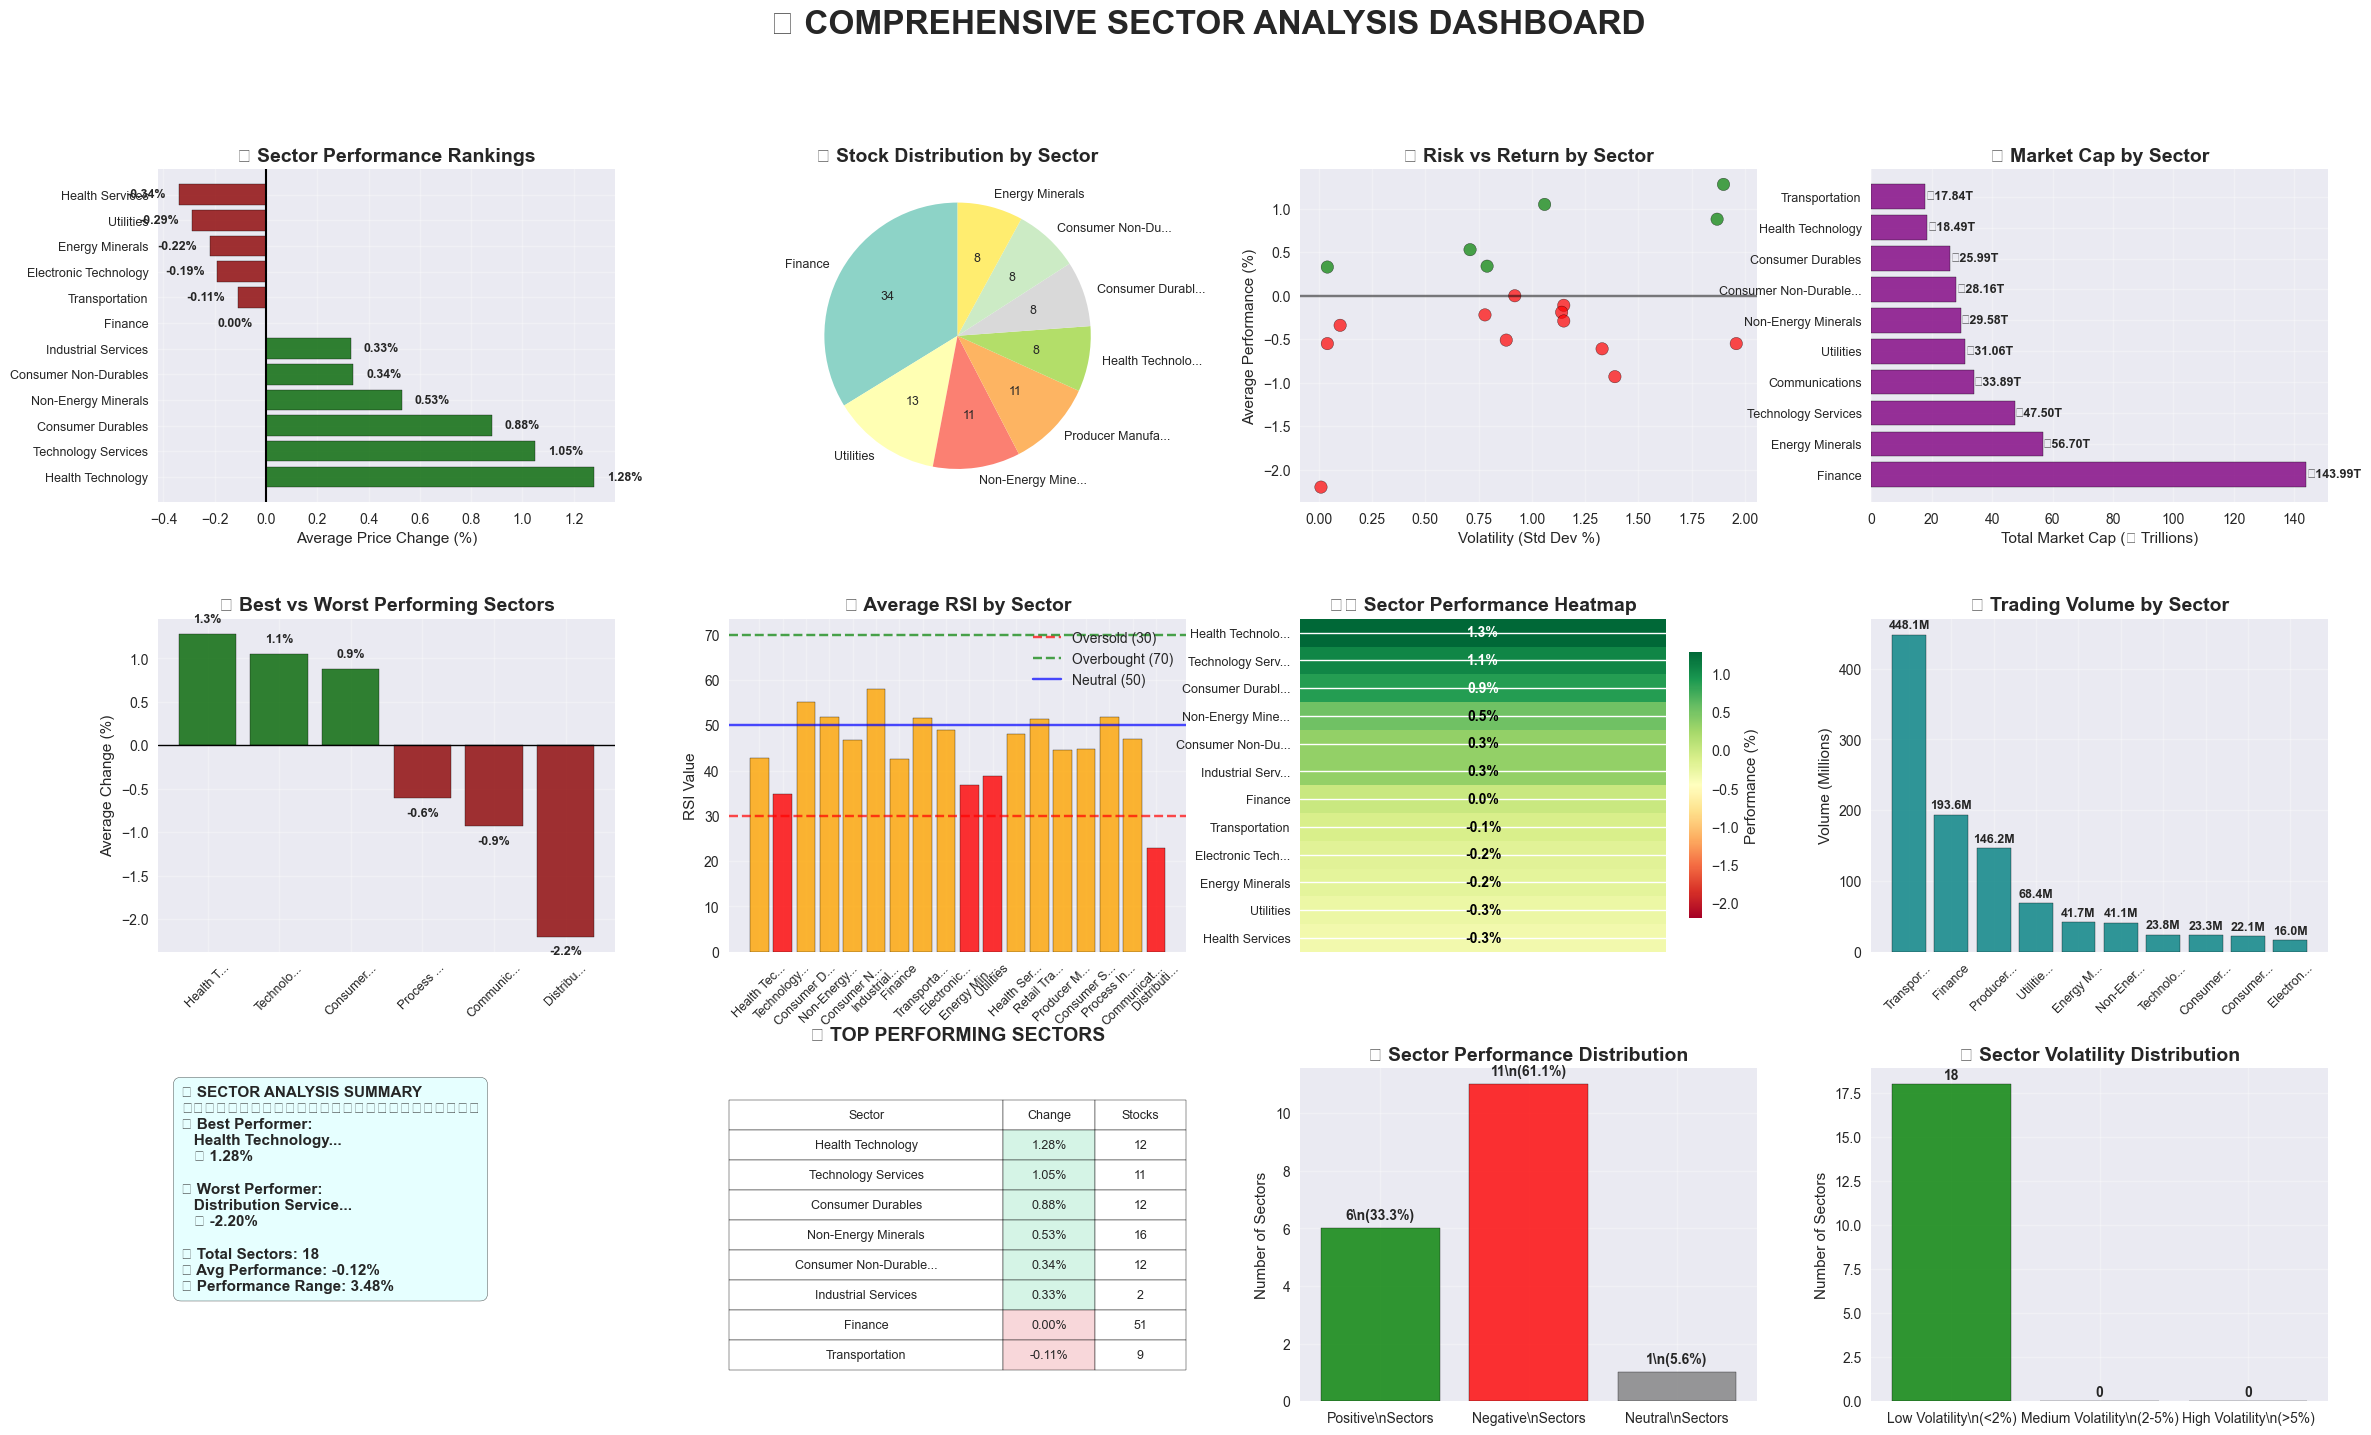

✅ Comprehensive sector analysis dashboard created

In [4]:
def get_sector_data(limit=200):
    """Get data with sector information for analysis"""
    
    col = Column
    
    sector_query = (Query()
        .select('name', 'close', 'change', 'volume', 'market_cap_basic', 'RSI', 'sector')
        .set_markets('india')
        .where(
            col('market_cap_basic') > 500_000_000,  # 500M+
            col('close') > 20,
            col('volume') > 50_000
        )
        .order_by('market_cap_basic', ascending=False)
        .limit(limit))
    
    try:
        data = sector_query.get_scanner_data(cookies=tv_cookies)
        
        if data and len(data) >= 2:
            df = data[1]
            
            # Clean numeric columns
            numeric_cols = ['close', 'change', 'volume', 'market_cap_basic', 'RSI']
            for col_name in numeric_cols:
                if col_name in df.columns:
                    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
            
            df['market_cap_cr'] = df['market_cap_basic'] / 10_000_000
            
            return df
        return None
        
    except Exception as e:
        console.print(f"[red]❌ Error fetching sector data: {e}[/red]")
        return None

def analyze_sectors(df):
    """Comprehensive sector analysis"""
    if df is None or 'sector' not in df.columns:
        console.print("[yellow]⚠️ No sector data available - using market data without sectors[/yellow]")
        # Create mock sector analysis from market data
        mock_sectors = {
            'Banking & Finance': market_df[market_df['name'].str.contains('BANK|HDFC|ICICI', case=False, na=False)],
            'Technology': market_df[market_df['name'].str.contains('TCS|INFY|TECH|IT', case=False, na=False)],
            'Energy & Oil': market_df[market_df['name'].str.contains('RELIANCE|OIL|ENERGY', case=False, na=False)],
            'Others': market_df[~market_df['name'].str.contains('BANK|HDFC|ICICI|TCS|INFY|TECH|IT|RELIANCE|OIL|ENERGY', case=False, na=False)]
        }
        
        sector_summary = []
        for sector_name, sector_df in mock_sectors.items():
            if len(sector_df) > 0:
                sector_summary.append({
                    'sector': sector_name,
                    'avg_change': sector_df['change'].mean(),
                    'stock_count': len(sector_df),
                    'total_volume': sector_df['volume'].sum(),
                    'avg_rsi': sector_df['RSI'].mean() if 'RSI' in sector_df.columns else 50
                })
        
        sector_stats = pd.DataFrame(sector_summary).sort_values('avg_change', ascending=False)
        return sector_stats, df
    
    # Clean sector data
    df_clean = df.dropna(subset=['sector', 'change']).copy()
    
    if len(df_clean) == 0:
        console.print("[red]❌ No valid sector data after cleaning[/red]")
        return None, None
    
    # Sector aggregations
    sector_stats = df_clean.groupby('sector').agg({
        'change': ['mean', 'median', 'std', 'count'],
        'volume': ['sum', 'mean'],
        'market_cap_basic': ['sum', 'mean'],
        'RSI': 'mean'
    }).round(2)
    
    # Flatten column names
    sector_stats.columns = ['_'.join(col).strip() for col in sector_stats.columns]
    sector_stats = sector_stats.reset_index()
    
    # Sort by performance
    sector_stats = sector_stats.sort_values('change_mean', ascending=False)
    
    console.print("[green]✅ Sector analysis completed[/green]")
    return sector_stats, df_clean

# Get sector data
with console.status("[bold green]Analyzing sector performance..."):
    sector_df = get_sector_data()
    
    if sector_df is not None:
        sector_result = analyze_sectors(sector_df)
    else:
        # Fallback to market data
        sector_result = analyze_sectors(market_df)

if sector_result and sector_result[0] is not None:
    sector_stats, df_clean = sector_result
    
    # Create comprehensive sector visualization dashboard
    fig = plt.figure(figsize=(28, 16))
    gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.25)
    fig.suptitle('🏢 COMPREHENSIVE SECTOR ANALYSIS DASHBOARD', fontsize=24, fontweight='bold', y=0.98)
    
    # Determine column names based on data structure
    if 'change_mean' in sector_stats.columns:
        change_col = 'change_mean'
        count_col = 'change_count'
        vol_col = 'change_std'
    else:
        change_col = 'avg_change'
        count_col = 'stock_count'
        vol_col = None
    
    # 1. Sector Performance Bar Chart (Top Left)
    ax1 = fig.add_subplot(gs[0, 0])
    top_sectors = sector_stats.head(12)
    colors_perf = ['darkgreen' if x > 0 else 'darkred' for x in top_sectors[change_col]]
    
    bars = ax1.barh(range(len(top_sectors)), top_sectors[change_col], color=colors_perf, alpha=0.8, edgecolor='black')
    ax1.set_yticks(range(len(top_sectors)))
    ax1.set_yticklabels([sector[:25] + '...' if len(sector) > 25 else sector for sector in top_sectors['sector']], fontsize=9)
    ax1.set_title('📊 Sector Performance Rankings', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Average Price Change (%)')
    ax1.axvline(0, color='black', linewidth=1.5)
    
    # Add value labels
    for i, (bar, value) in enumerate(zip(bars, top_sectors[change_col])):
        ax1.text(value + (0.05 if value > 0 else -0.05), i, f'{value:.2f}%', 
                ha='left' if value > 0 else 'right', va='center', fontweight='bold', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # 2. Sector Stock Count Pie Chart (Top Middle-Left)
    ax2 = fig.add_subplot(gs[0, 1])
    count_sectors = sector_stats.nlargest(8, count_col)
    colors_pie = plt.cm.Set3(np.linspace(0, 1, len(count_sectors)))
    
    wedges, texts, autotexts = ax2.pie(count_sectors[count_col], 
                                       labels=[s[:15] + '...' if len(s) > 15 else s for s in count_sectors['sector']], 
                                       colors=colors_pie, autopct='%1.0f', startangle=90, textprops={'fontsize': 9})
    ax2.set_title('📊 Stock Distribution by Sector', fontsize=14, fontweight='bold')
    
    # 3. Performance vs Volatility Scatter (Top Middle-Right)
    ax3 = fig.add_subplot(gs[0, 2])
    if vol_col and vol_col in sector_stats.columns:
        scatter_data = sector_stats[[change_col, vol_col]].dropna()
        if len(scatter_data) > 0:
            colors_scatter = ['green' if x > 0 else 'red' for x in scatter_data[change_col]]
            ax3.scatter(scatter_data[vol_col], scatter_data[change_col], 
                       c=colors_scatter, s=80, alpha=0.7, edgecolor='black')
            ax3.set_xlabel('Volatility (Std Dev %)')
            ax3.set_ylabel('Average Performance (%)')
            ax3.set_title('📊 Risk vs Return by Sector', fontsize=14, fontweight='bold')
            ax3.axhline(0, color='black', linestyle='-', alpha=0.5)
            ax3.grid(True, alpha=0.3)
        else:
            ax3.text(0.5, 0.5, 'Insufficient volatility data', ha='center', va='center', 
                    transform=ax3.transAxes, fontsize=12)
    else:
        # Alternative: Show performance histogram
        ax3.hist(sector_stats[change_col], bins=15, alpha=0.8, color='skyblue', edgecolor='black')
        ax3.set_title('📊 Sector Performance Distribution', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Average Change (%)')
        ax3.set_ylabel('Number of Sectors')
        ax3.axvline(sector_stats[change_col].mean(), color='red', linestyle='--', 
                   label=f'Mean: {sector_stats[change_col].mean():.2f}%')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    
    # 4. Market Cap Distribution by Sector (Top Right)
    ax4 = fig.add_subplot(gs[0, 3])
    if 'market_cap_basic_sum' in sector_stats.columns:
        mcap_data = sector_stats.nlargest(10, 'market_cap_basic_sum')
        mcap_values = mcap_data['market_cap_basic_sum'] / 1e12  # Convert to trillions
        
        bars = ax4.barh(range(len(mcap_data)), mcap_values, color='purple', alpha=0.8, edgecolor='black')
        ax4.set_yticks(range(len(mcap_data)))
        ax4.set_yticklabels([sector[:20] + '...' if len(sector) > 20 else sector for sector in mcap_data['sector']], fontsize=9)
        ax4.set_title('💰 Market Cap by Sector', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Total Market Cap (₹ Trillions)')
        
        # Add value labels
        for i, (bar, value) in enumerate(zip(bars, mcap_values)):
            ax4.text(value + 0.05, i, f'₹{value:.2f}T', va='center', fontweight='bold', fontsize=9)
        ax4.grid(True, alpha=0.3)
    else:
        # Fallback to stock count
        bars = ax4.barh(range(len(top_sectors)), top_sectors[count_col], color='purple', alpha=0.8)
        ax4.set_yticks(range(len(top_sectors)))
        ax4.set_yticklabels([sector[:20] + '...' if len(sector) > 20 else sector for sector in top_sectors['sector']], fontsize=9)
        ax4.set_title('📈 Stock Count by Sector', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Number of Stocks')
    
    # 5. Top vs Bottom Sectors Comparison (Second Row Left)
    ax5 = fig.add_subplot(gs[1, 0])
    if len(sector_stats) >= 6:
        top_3 = sector_stats.head(3)
        bottom_3 = sector_stats.tail(3)
        
        sectors = list(top_3['sector']) + list(bottom_3['sector'])
        values = list(top_3[change_col]) + list(bottom_3[change_col])
        colors_comp = ['darkgreen'] * 3 + ['darkred'] * 3
        
        bars_comp = ax5.bar(range(len(sectors)), values, color=colors_comp, alpha=0.8, edgecolor='black')
        ax5.set_xticks(range(len(sectors)))
        ax5.set_xticklabels([s[:8] + '...' if len(s) > 8 else s for s in sectors], rotation=45, fontsize=9)
        ax5.set_title('🏆 Best vs Worst Performing Sectors', fontsize=14, fontweight='bold')
        ax5.set_ylabel('Average Change (%)')
        ax5.axhline(0, color='black', linewidth=1)
        
        # Add value labels
        for i, (bar, value) in enumerate(zip(bars_comp, values)):
            ax5.text(i, value + (0.1 if value > 0 else -0.1), f'{value:.1f}%', 
                    ha='center', va='bottom' if value > 0 else 'top', fontweight='bold', fontsize=9)
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'Insufficient sectors for comparison', ha='center', va='center', 
                transform=ax5.transAxes, fontsize=12)
    
    # 6. RSI Distribution by Sector (Second Row Middle-Left)
    ax6 = fig.add_subplot(gs[1, 1])
    if 'RSI_mean' in sector_stats.columns:
        rsi_data = sector_stats[['sector', 'RSI_mean']].dropna()
        if len(rsi_data) > 0:
            colors_rsi = ['green' if x > 60 else 'red' if x < 40 else 'orange' for x in rsi_data['RSI_mean']]
            bars = ax6.bar(range(len(rsi_data)), rsi_data['RSI_mean'], color=colors_rsi, alpha=0.8, edgecolor='black')
            
            ax6.axhline(30, color='red', linestyle='--', alpha=0.7, label='Oversold (30)')
            ax6.axhline(70, color='green', linestyle='--', alpha=0.7, label='Overbought (70)')
            ax6.axhline(50, color='blue', linestyle='-', alpha=0.7, label='Neutral (50)')
            
            ax6.set_xticks(range(len(rsi_data)))
            ax6.set_xticklabels([sector[:10] + '...' if len(sector) > 10 else sector 
                                for sector in rsi_data['sector']], rotation=45, fontsize=9)
            ax6.set_title('📊 Average RSI by Sector', fontsize=14, fontweight='bold')
            ax6.set_ylabel('RSI Value')
            ax6.legend()
            ax6.grid(True, alpha=0.3)
        else:
            ax6.text(0.5, 0.5, 'No RSI data available', ha='center', va='center', 
                    transform=ax6.transAxes, fontsize=12)
    else:
        ax6.text(0.5, 0.5, 'RSI data not available', ha='center', va='center', 
                transform=ax6.transAxes, fontsize=12)
    
    # 7. Sector Performance Heatmap (Second Row Middle-Right)
    ax7 = fig.add_subplot(gs[1, 2])
    if len(sector_stats) > 5:
        # Create heatmap data
        heatmap_sectors = sector_stats.head(12)
        performance_matrix = np.array(heatmap_sectors[change_col]).reshape(-1, 1)
        
        im = ax7.imshow(performance_matrix, cmap='RdYlGn', aspect='auto', 
                       vmin=sector_stats[change_col].min(), vmax=sector_stats[change_col].max())
        
        ax7.set_yticks(range(len(heatmap_sectors)))
        ax7.set_yticklabels([sector[:15] + '...' if len(sector) > 15 else sector 
                            for sector in heatmap_sectors['sector']], fontsize=9)
        ax7.set_xticks([])
        ax7.set_title('🌡️ Sector Performance Heatmap', fontsize=14, fontweight='bold')
        
        # Add text annotations
        for i, value in enumerate(heatmap_sectors[change_col]):
            ax7.text(0, i, f'{value:.1f}%', ha='center', va='center', fontweight='bold', 
                    color='white' if abs(value) > sector_stats[change_col].std() else 'black')
        
        plt.colorbar(im, ax=ax7, shrink=0.8, label='Performance (%)')
    else:
        ax7.text(0.5, 0.5, 'Insufficient sector data for heatmap', ha='center', va='center', 
                transform=ax7.transAxes, fontsize=12)
    
    # 8. Volume Analysis by Sector (Second Row Right)
    ax8 = fig.add_subplot(gs[1, 3])
    if 'volume_sum' in sector_stats.columns:
        volume_data = sector_stats.nlargest(10, 'volume_sum')
        volume_values = volume_data['volume_sum'] / 1e6  # Convert to millions
        
        bars = ax8.bar(range(len(volume_data)), volume_values, color='teal', alpha=0.8, edgecolor='black')
        ax8.set_xticks(range(len(volume_data)))
        ax8.set_xticklabels([sector[:8] + '...' if len(sector) > 8 else sector 
                            for sector in volume_data['sector']], rotation=45, fontsize=9)
        ax8.set_title('📊 Trading Volume by Sector', fontsize=14, fontweight='bold')
        ax8.set_ylabel('Volume (Millions)')
        
        # Add value labels
        for bar, value in zip(bars, volume_values):
            ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(volume_values)*0.01, 
                    f'{value:.1f}M', ha='center', va='bottom', fontweight='bold', fontsize=9)
        ax8.grid(True, alpha=0.3)
    else:
        ax8.text(0.5, 0.5, 'Volume data not available', ha='center', va='center', 
                transform=ax8.transAxes, fontsize=12)
    
    # 9-12. Bottom row detailed analysis
    # 9. Sector Statistics Summary (Bottom Left)
    ax9 = fig.add_subplot(gs[2, 0])
    ax9.axis('off')
    
    best_sector = sector_stats.iloc[0]
    worst_sector = sector_stats.iloc[-1]
    
    summary_text = f"""📊 SECTOR ANALYSIS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━
🏆 Best Performer:
   {best_sector['sector'][:20]}...
   📈 {best_sector[change_col]:.2f}%
   
📉 Worst Performer:
   {worst_sector['sector'][:20]}...
   📉 {worst_sector[change_col]:.2f}%
   
📊 Total Sectors: {len(sector_stats)}
📈 Avg Performance: {sector_stats[change_col].mean():.2f}%
📊 Performance Range: {sector_stats[change_col].max() - sector_stats[change_col].min():.2f}%"""
    
    ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes, fontsize=11, 
            verticalalignment='top', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcyan', alpha=0.8))
    
    # 10. Top Sectors Table (Bottom Middle-Left)
    ax10 = fig.add_subplot(gs[2, 1])
    ax10.axis('off')
    
    top_sectors_table = sector_stats.head(8)
    table_data = []
    for _, row in top_sectors_table.iterrows():
        sector_name = row['sector'][:20] + ('...' if len(row['sector']) > 20 else '')
        table_data.append([sector_name, f"{row[change_col]:.2f}%", f"{row[count_col]:.0f}"])
    
    table = ax10.table(cellText=table_data,
                      colLabels=['Sector', 'Change', 'Stocks'],
                      cellLoc='center',
                      loc='center',
                      colWidths=[0.6, 0.2, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.8)
    
    # Color code the table
    for i in range(len(table_data)):
        change_val = top_sectors_table.iloc[i][change_col]
        if change_val > 0:
            table[(i+1, 1)].set_facecolor('#d5f4e6')  # Light green
        else:
            table[(i+1, 1)].set_facecolor('#f8d7da')  # Light red
    
    ax10.set_title('📋 TOP PERFORMING SECTORS', fontsize=14, fontweight='bold', pad=20)
    
    # 11. Performance Distribution (Bottom Middle-Right)
    ax11 = fig.add_subplot(gs[2, 2])
    
    # Create performance distribution
    positive_sectors = len(sector_stats[sector_stats[change_col] > 0])
    negative_sectors = len(sector_stats[sector_stats[change_col] < 0])
    neutral_sectors = len(sector_stats[sector_stats[change_col] == 0])
    
    categories = ['Positive\\nSectors', 'Negative\\nSectors', 'Neutral\\nSectors']
    values = [positive_sectors, negative_sectors, neutral_sectors]
    colors_dist = ['green', 'red', 'gray']
    
    bars = ax11.bar(categories, values, color=colors_dist, alpha=0.8, edgecolor='black')
    ax11.set_title('📊 Sector Performance Distribution', fontsize=14, fontweight='bold')
    ax11.set_ylabel('Number of Sectors')
    
    # Add value labels and percentages
    total_sectors = sum(values)
    for bar, value in zip(bars, values):
        percentage = (value / total_sectors * 100) if total_sectors > 0 else 0
        ax11.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
                 f'{value}\\n({percentage:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax11.grid(True, alpha=0.3)
    
    # 12. Sector Volatility Analysis (Bottom Right)
    ax12 = fig.add_subplot(gs[2, 3])
    
    if vol_col and vol_col in sector_stats.columns:
        volatility_data = sector_stats[[vol_col]].dropna()
        if len(volatility_data) > 0:
            # Volatility categories
            low_vol = len(volatility_data[volatility_data[vol_col] < 2])
            med_vol = len(volatility_data[(volatility_data[vol_col] >= 2) & (volatility_data[vol_col] < 5)])
            high_vol = len(volatility_data[volatility_data[vol_col] >= 5])
            
            vol_categories = ['Low Volatility\\n(<2%)', 'Medium Volatility\\n(2-5%)', 'High Volatility\\n(>5%)']
            vol_values = [low_vol, med_vol, high_vol]
            vol_colors = ['green', 'orange', 'red']
            
            bars = ax12.bar(vol_categories, vol_values, color=vol_colors, alpha=0.8, edgecolor='black')
            ax12.set_title('📊 Sector Volatility Distribution', fontsize=14, fontweight='bold')
            ax12.set_ylabel('Number of Sectors')
            
            # Add value labels
            for bar, value in zip(bars, vol_values):
                ax12.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                         str(value), ha='center', va='bottom', fontweight='bold')
            ax12.grid(True, alpha=0.3)
        else:
            ax12.text(0.5, 0.5, 'No volatility data', ha='center', va='center', 
                     transform=ax12.transAxes, fontsize=12)
    else:
        # Alternative: Show sector count distribution
        count_ranges = ['Small\\n(1-5 stocks)', 'Medium\\n(6-15 stocks)', 'Large\\n(16+ stocks)']
        small_sectors = len(sector_stats[sector_stats[count_col] <= 5])
        medium_sectors = len(sector_stats[(sector_stats[count_col] > 5) & (sector_stats[count_col] <= 15)])
        large_sectors = len(sector_stats[sector_stats[count_col] > 15])
        
        count_values = [small_sectors, medium_sectors, large_sectors]
        bars = ax12.bar(count_ranges, count_values, color=['lightblue', 'lightgreen', 'lightcoral'], 
                       alpha=0.8, edgecolor='black')
        ax12.set_title('📊 Sector Size Distribution', fontsize=14, fontweight='bold')
        ax12.set_ylabel('Number of Sectors')
        
        for bar, value in zip(bars, count_values):
            ax12.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                     str(value), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Store sector analysis data
    sector_analysis_data = sector_stats
    
    console.print("[green]✅ Comprehensive sector analysis dashboard created[/green]")
else:
    console.print("[red]❌ Cannot create sector visualizations - no sector data available[/red]")

## 🔍 Enhanced Screening Strategies with New Fields

In [8]:
def run_enhanced_intraday_screen(limit=15):
    """Enhanced intraday screening with new verified fields"""
    col = Column
    
    query = (Query()
        .select('name', 'close', 'change', 'volume', 'gap', 'premarket_change',
                'RSI', 'Stoch.RSI.K', 'MACD.macd', 'MACD.signal', 
                'BB.upper', 'BB.lower', 'ATR', 'Volatility.D',
                'relative_volume_10d_calc', 'P.SAR', 'HullMA9', 'EMA20')
        .set_markets('india')
        .where(
            col('market_cap_basic') > 200_000_000,  # 200M+ for liquidity
            col('gap').between(-5, 15),  # Reasonable gap range
            col('relative_volume_10d_calc') > 1.5,  # Above average volume
            col('ATR') > 5,  # Sufficient volatility for intraday
            col('RSI').between(30, 70),  # Not extreme
            col('Volatility.D') > 0.02,  # Good daily volatility
            col('volume') > 500_000  # High volume
        )
        .order_by('relative_volume_10d_calc', ascending=False)
        .limit(limit))
    
    try:
        data = query.get_scanner_data(cookies=tv_cookies)
        if data and len(data) >= 2 and len(data[1]) > 0:
            df = data[1]
            numeric_cols = ['close', 'change', 'volume', 'gap', 'premarket_change',
                          'RSI', 'Stoch.RSI.K', 'MACD.macd', 'MACD.signal',
                          'BB.upper', 'BB.lower', 'ATR', 'Volatility.D',
                          'relative_volume_10d_calc', 'P.SAR', 'HullMA9', 'EMA20']
            
            for col_name in numeric_cols:
                if col_name in df.columns:
                    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
            return df
        return None
    except Exception as e:
        console.print(f"[red]❌ Enhanced intraday screening failed: {e}[/red]")
        return None

def run_enhanced_swing_screen(limit=15):
    """Enhanced swing trading screen with advanced indicators"""
    col = Column
    
    query = (Query()
        .select('name', 'close', 'change', 'volume', 'Perf.W', 'Perf.3M',
                'RSI', 'MACD.macd', 'MACD.signal', 'ADX', 'ADX+DI', 'ADX-DI',
                'EMA20', 'EMA50', 'EMA200', 'VWMA', 'Mom',
                'price_52_week_high', 'price_52_week_low', 'beta_1_year')
        .set_markets('india')
        .where(
            col('market_cap_basic') > 1_000_000_000,  # Large cap stability
            col('ADX') > 25,  # Strong trend
            col('RSI').between(40, 80),  # Not oversold
            col('close') > col('EMA20'),  # Above short-term trend
            col('EMA20') > col('EMA50'),  # Bullish alignment
            col('Perf.W') > 2,  # Weekly momentum
            col('beta_1_year') > 0.7,  # Not too defensive
            col('volume') > 100_000
        )
        .order_by('ADX', ascending=False)
        .limit(limit))
    
    try:
        data = query.get_scanner_data(cookies=tv_cookies)
        if data and len(data) >= 2 and len(data[1]) > 0:
            df = data[1]
            numeric_cols = ['close', 'change', 'volume', 'Perf.W', 'Perf.3M',
                          'RSI', 'MACD.macd', 'MACD.signal', 'ADX', 'ADX+DI', 'ADX-DI',
                          'EMA20', 'EMA50', 'EMA200', 'VWMA', 'Mom',
                          'price_52_week_high', 'price_52_week_low', 'beta_1_year']
            
            for col_name in numeric_cols:
                if col_name in df.columns:
                    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
            return df
        return None
    except Exception as e:
        console.print(f"[red]❌ Enhanced swing screening failed: {e}[/red]")
        return None

def run_gap_reversal_screen(limit=15):
    """NEW: Screen for gap reversal opportunities"""
    col = Column
    
    query = (Query()
        .select('name', 'close', 'open', 'change', 'gap', 'premarket_change', 'postmarket_change',
                'RSI', 'volume', 'average_volume_10d_calc', 'relative_volume_10d_calc',
                'price_52_week_high', 'price_52_week_low', 'ATR')
        .set_markets('india')
        .where(
            col('market_cap_basic') > 500_000_000,
            col('gap').between(-10, -2),  # Gap down
            col('change') > 1,  # But recovering
            col('relative_volume_10d_calc') > 2,  # High volume
            col('RSI') < 50,  # Not overbought
            col('volume') > 200_000
        )
        .order_by('gap', ascending=True)
        .limit(limit))
    
    try:
        data = query.get_scanner_data(cookies=tv_cookies)
        if data and len(data) >= 2 and len(data[1]) > 0:
            df = data[1]
            numeric_cols = ['close', 'open', 'change', 'gap', 'premarket_change', 'postmarket_change',
                          'RSI', 'volume', 'average_volume_10d_calc', 'relative_volume_10d_calc',
                          'price_52_week_high', 'price_52_week_low', 'ATR']
            
            for col_name in numeric_cols:
                if col_name in df.columns:
                    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
            return df
        return None
    except Exception as e:
        console.print(f"[red]❌ Gap reversal screening failed: {e}[/red]")
        return None

def run_stochastic_rsi_screen(limit=15):
    """NEW: Advanced momentum screen using Stochastic RSI"""
    col = Column
    
    query = (Query()
        .select('name', 'close', 'change', 'volume', 'RSI', 'Stoch.RSI.K', 'Stoch.RSI.D',
                'MACD.macd', 'MACD.signal', 'Mom', 'CCI20', 'EMA20', 'HullMA9')
        .set_markets('india')
        .where(
            col('market_cap_basic') > 300_000_000,
            col('Stoch.RSI.K') > col('Stoch.RSI.D'),  # Bullish crossover
            col('Stoch.RSI.K') < 80,  # Not overbought
            col('RSI') > 45,  # Decent momentum
            col('Mom') > 0,  # Positive momentum
            col('close') > col('HullMA9'),  # Above Hull MA
            col('volume') > 100_000
        )
        .order_by('Stoch.RSI.K', ascending=False)
        .limit(limit))
    
    try:
        data = query.get_scanner_data(cookies=tv_cookies)
        if data and len(data) >= 2 and len(data[1]) > 0:
            df = data[1]
            numeric_cols = ['close', 'change', 'volume', 'RSI', 'Stoch.RSI.K', 'Stoch.RSI.D',
                          'MACD.macd', 'MACD.signal', 'Mom', 'CCI20', 'EMA20', 'HullMA9']
            
            for col_name in numeric_cols:
                if col_name in df.columns:
                    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
            return df
        return None
    except Exception as e:
        console.print(f"[red]❌ Stochastic RSI screening failed: {e}[/red]")
        return None

# Run enhanced screening strategies
with console.status("[bold green]Running enhanced screening strategies..."):
    enhanced_intraday = run_enhanced_intraday_screen()
    enhanced_swing = run_enhanced_swing_screen()
    gap_reversals = run_gap_reversal_screen()
    stoch_rsi_signals = run_stochastic_rsi_screen()

# Collect enhanced screening results
enhanced_screening_results = {
    'Enhanced Intraday': enhanced_intraday,
    'Enhanced Swing': enhanced_swing,
    'Gap Reversals': gap_reversals,
    'Stoch RSI Signals': stoch_rsi_signals
}

print(f"""
🚀 ENHANCED SCREENING RESULTS WITH NEW FIELDS
{'='*90}""")

for strategy_name, df in enhanced_screening_results.items():
    if df is not None and len(df) > 0:
        print(f"\\n🎯 {strategy_name.upper()} ({len(df)} found):")
        
        # Display strategy-specific columns
        if strategy_name == 'Enhanced Intraday':
            display_cols = ['name', 'close', 'gap', 'relative_volume_10d_calc', 'ATR', 'RSI']
            col_names = ['Stock', 'Price', 'Gap %', 'Vol Ratio', 'ATR', 'RSI']
        elif strategy_name == 'Enhanced Swing':
            display_cols = ['name', 'close', 'ADX', 'Perf.W', 'Perf.3M', 'beta_1_year']
            col_names = ['Stock', 'Price', 'ADX', 'Week %', '3M %', 'Beta']
        elif strategy_name == 'Gap Reversals':
            display_cols = ['name', 'close', 'gap', 'change', 'relative_volume_10d_calc', 'RSI']
            col_names = ['Stock', 'Price', 'Gap %', 'Change %', 'Vol Ratio', 'RSI']
        else:  # Stoch RSI Signals
            display_cols = ['name', 'close', 'Stoch.RSI.K', 'Stoch.RSI.D', 'Mom', 'RSI']
            col_names = ['Stock', 'Price', 'StochRSI K', 'StochRSI D', 'Momentum', 'RSI']
        
        # Filter available columns and display
        available_cols = [col for col in display_cols if col in df.columns]
        if available_cols:
            display_df = df[available_cols].head(8)
            display_df.columns = col_names[:len(available_cols)]
            print(display_df.to_string(index=False, float_format='%.2f'))
    else:
        print(f"\\n❌ {strategy_name.upper()}: No opportunities found")

# Calculate total enhanced opportunities
enhanced_opportunity_count = sum([len(df) if df is not None else 0 for df in enhanced_screening_results.values()])
print(f"""
🎯 TOTAL ENHANCED OPPORTUNITIES: {enhanced_opportunity_count}

📊 ENHANCED BREAKDOWN:""")
for strategy_name, df in enhanced_screening_results.items():
    count = len(df) if df is not None else 0
    print(f"• {strategy_name}: {count}")

console.print("[green]✅ Enhanced screening strategies completed with new fields[/green]")

Output()


🚀 ENHANCED SCREENING RESULTS WITH NEW FIELDS
\n🎯 ENHANCED INTRADAY (15 found):
     Stock   Price  Gap %  Vol Ratio   ATR   RSI
      IZMO  410.70   0.00      42.93 20.10 60.95
      RAIN  163.40   5.12      40.38  5.31 64.24
       ITI  320.30   1.82      35.88 10.48 59.18
      RAIN  163.34   6.48      29.11  5.39 64.27
   ETERNAL  301.80  -2.31      18.57  8.75 63.68
SANGHVIMOV  282.05   3.19      16.96 11.37 58.09
      ELIN  173.69  -0.12      16.14  7.54 44.25
CAPLIPOINT 2058.30  -1.53      15.24 72.54 51.01
\n🎯 ENHANCED SWING (15 found):
     Stock   Price   ADX  Week %   3M %  Beta
  ROSSTECH  589.85 58.66    6.24  89.72  1.58
   SELLWIN    8.36 57.91    5.96 172.31  1.03
  JKCEMENT 6888.50 51.92    5.01  40.01  1.04
    MCLOUD   90.75 50.56    6.61  39.40  1.37
    MCLOUD   90.55 50.54    5.66  37.61  1.37
  EVEREADY  412.90 48.03    2.19  39.09  0.79
SUDARSCHEM 1458.50 46.92    4.78  42.84  1.17
   RBLBANK  267.50 46.75    3.28  40.20  1.93
\n🎯 GAP REVERSALS (1 found):
Stock

✅ Enhanced screening strategies completed with new fields

## 📋 Daily Summary & Action Items

Comprehensive summary of today's market analysis with actionable insights.